In [1]:
# import libraries
import pandas as pd
import numpy as np
import sklearn 
import seaborn as sbs

In [2]:
# import data from csv file using pandas
data = pd.read_csv('train.csv')
print(data.shape) # checking the shape
# check the head of dataframe
data.head(20)

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [3]:
# Check data types and non-null count in the data
# As seen below, there are columns with null values in the dataset.
# Some columns such as Alley contains only a few valid data. 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
# Get the names of the columns
cols = data.columns
cols

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
# divide the columns into categorical and non-categorical columns by check the unique values in a column
# If the numer of unique values in a column is less than 25, the column is regarded as discrete data
# Otherwise, non-categorical columns
category_cols = []
non_category_cols = []
threshold = 25
for i in range(len(cols)):
    if len(pd.unique(data[cols[i]])) > threshold:
        non_category_cols.append(cols[i])
    else:
        category_cols.append(cols[i])

print(non_category_cols)
print(category_cols)

['Id', 'LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'SalePrice']
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', '3SsnPorch', 'PoolA

In [6]:
pd.unique(data.CentralAir)
pd.unique(data.LotFrontage)

array([ 65.,  80.,  68.,  60.,  84.,  85.,  75.,  nan,  51.,  50.,  70.,
        91.,  72.,  66., 101.,  57.,  44., 110.,  98.,  47., 108., 112.,
        74., 115.,  61.,  48.,  33.,  52., 100.,  24.,  89.,  63.,  76.,
        81.,  95.,  69.,  21.,  32.,  78., 121., 122.,  40., 105.,  73.,
        77.,  64.,  94.,  34.,  90.,  55.,  88.,  82.,  71., 120., 107.,
        92., 134.,  62.,  86., 141.,  97.,  54.,  41.,  79., 174.,  99.,
        67.,  83.,  43., 103.,  93.,  30., 129., 140.,  35.,  37., 118.,
        87., 116., 150., 111.,  49.,  96.,  59.,  36.,  56., 102.,  58.,
        38., 109., 130.,  53., 137.,  45., 106., 104.,  42.,  39., 144.,
       114., 128., 149., 313., 168., 182., 138., 160., 152., 124., 153.,
        46.])

In [7]:
len(category_cols)
len(non_category_cols)

20

In [8]:
# Extracting the unique values in each categorical column
category_dict = {}
for col in category_cols:
    category_dict[col]=pd.unique(data[col])
category_dict

{'MSSubClass': array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
        180,  40], dtype=int64),
 'MSZoning': array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object),
 'Street': array(['Pave', 'Grvl'], dtype=object),
 'Alley': array([nan, 'Grvl', 'Pave'], dtype=object),
 'LotShape': array(['Reg', 'IR1', 'IR2', 'IR3'], dtype=object),
 'LandContour': array(['Lvl', 'Bnk', 'Low', 'HLS'], dtype=object),
 'Utilities': array(['AllPub', 'NoSeWa'], dtype=object),
 'LotConfig': array(['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3'], dtype=object),
 'LandSlope': array(['Gtl', 'Mod', 'Sev'], dtype=object),
 'Neighborhood': array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
        'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
        'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
        'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
        'Blueste'], dtype=object),
 'Condition1': array(['Norm', 'Feedr', 

In [9]:
# Checking the datatypes of non-categorical columns
print(len(non_category_cols))
data[non_category_cols].dtypes

20


Id                 int64
LotFrontage      float64
LotArea            int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
GrLivArea          int64
GarageYrBlt      float64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
ScreenPorch        int64
SalePrice          int64
dtype: object

In [10]:
# Checking the datatypes of non-categorical columns
print(len(category_cols))
data[category_cols].dtypes

61


MSSubClass        int64
MSZoning         object
Street           object
Alley            object
LotShape         object
                  ...  
MiscVal           int64
MoSold            int64
YrSold            int64
SaleType         object
SaleCondition    object
Length: 61, dtype: object

In [11]:
# getting the shape of the dataset
(m,n) = data.shape
m,n

(1460, 81)

In [12]:
# check non-null value counts in each column
dataCount = data.count()
dataCount

Id               1460
MSSubClass       1460
MSZoning         1460
LotFrontage      1201
LotArea          1460
                 ... 
MoSold           1460
YrSold           1460
SaleType         1460
SaleCondition    1460
SalePrice        1460
Length: 81, dtype: int64

In [13]:
dataCount<m

Id               False
MSSubClass       False
MSZoning         False
LotFrontage       True
LotArea          False
                 ...  
MoSold           False
YrSold           False
SaleType         False
SaleCondition    False
SalePrice        False
Length: 81, dtype: bool

In [14]:
# check columns with Nan
nullCol = dataCount[dataCount<m].index
print(nullCol)
print(f'There are {len(nullCol):d} columns containing NaN.')

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')
There are 19 columns containing NaN.


In [15]:
data[nullCol].count()

LotFrontage     1201
Alley             91
MasVnrType       588
MasVnrArea      1452
BsmtQual        1423
BsmtCond        1423
BsmtExposure    1422
BsmtFinType1    1423
BsmtFinType2    1422
Electrical      1459
FireplaceQu      770
GarageType      1379
GarageYrBlt     1379
GarageFinish    1379
GarageQual      1379
GarageCond      1379
PoolQC             7
Fence            281
MiscFeature       54
dtype: int64

In [16]:
# Check how much percentage of the data is valid values in columns containing null values
nullColCount = data[nullCol].count()/m*100
nullColCount

LotFrontage     82.260274
Alley            6.232877
MasVnrType      40.273973
MasVnrArea      99.452055
BsmtQual        97.465753
BsmtCond        97.465753
BsmtExposure    97.397260
BsmtFinType1    97.465753
BsmtFinType2    97.397260
Electrical      99.931507
FireplaceQu     52.739726
GarageType      94.452055
GarageYrBlt     94.452055
GarageFinish    94.452055
GarageQual      94.452055
GarageCond      94.452055
PoolQC           0.479452
Fence           19.246575
MiscFeature      3.698630
dtype: float64

In [17]:
# check columns with less than 53% valid data and name it as dropCol
dropCol = nullColCount[nullColCount<53]
dropCol

Alley           6.232877
MasVnrType     40.273973
FireplaceQu    52.739726
PoolQC          0.479452
Fence          19.246575
MiscFeature     3.698630
dtype: float64

In [18]:
cleanCol = nullColCount[nullColCount>53]
cleanCol

LotFrontage     82.260274
MasVnrArea      99.452055
BsmtQual        97.465753
BsmtCond        97.465753
BsmtExposure    97.397260
BsmtFinType1    97.465753
BsmtFinType2    97.397260
Electrical      99.931507
GarageType      94.452055
GarageYrBlt     94.452055
GarageFinish    94.452055
GarageQual      94.452055
GarageCond      94.452055
dtype: float64

In [19]:
# remove dropCol from the dataset since there are few valid data in the columns
df = data.drop(dropCol.index,axis=1)
print(df.columns)
print(df.shape)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enclo

In [20]:
# check how many samples are non-Null values in cleanCol
df[cleanCol.index].count()

LotFrontage     1201
MasVnrArea      1452
BsmtQual        1423
BsmtCond        1423
BsmtExposure    1422
BsmtFinType1    1423
BsmtFinType2    1422
Electrical      1459
GarageType      1379
GarageYrBlt     1379
GarageFinish    1379
GarageQual      1379
GarageCond      1379
dtype: int64

In [21]:
df.shape

(1460, 75)

In [22]:
# drop rows with null values from clean columns after copying the dataset
df2 = df.copy()
df2.dropna(inplace=True)
df2.shape

(1094, 75)

In [23]:
df2.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,IR1,Lvl,AllPub,Inside,...,0,320,0,0,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,307000
8,9,50,RM,51.0,6120,Pave,Reg,Lvl,AllPub,Inside,...,205,0,0,0,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2008,WD,Normal,118000
10,11,20,RL,70.0,11200,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,129500


In [24]:
losspercent = (m-df2.shape[0])/m*100
losspercent

25.068493150684933

In [25]:
# just check what are the cleanCols
cleanCols = cleanCol.index
cleanCols

Index(['LotFrontage', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond'],
      dtype='object')

In [26]:
print(df2.shape) # check the shape of the datset. 
# After dropping columns with few valid data and rows with NaN from remaining columns, the data set
# now has 1094 samples and 75 features left.
df2.head()

(1094, 75)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [27]:
# Just confirming clean data
df2.count()

Id               1094
MSSubClass       1094
MSZoning         1094
LotFrontage      1094
LotArea          1094
                 ... 
MoSold           1094
YrSold           1094
SaleType         1094
SaleCondition    1094
SalePrice        1094
Length: 75, dtype: int64

In [28]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='mean')

In [29]:
# data imputation of numeric columns using mean strategy
df3 = df.copy()
for col in cleanCols:
    if df3[col].dtypes != 'object':
        df3[col] = imp.fit_transform(df3[col].values.reshape(-1,1))
df3.head(50)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000000,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000000,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000000,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000000,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000000,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
5,6,50,RL,85.000000,14115,Pave,IR1,Lvl,AllPub,Inside,...,0,320,0,0,700,10,2009,WD,Normal,143000
6,7,20,RL,75.000000,10084,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,307000
7,8,60,RL,70.049958,10382,Pave,IR1,Lvl,AllPub,Corner,...,228,0,0,0,350,11,2009,WD,Normal,200000
8,9,50,RM,51.000000,6120,Pave,Reg,Lvl,AllPub,Inside,...,205,0,0,0,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.000000,7420,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2008,WD,Normal,118000


In [30]:
df3.head(20)
df3.loc[7,'LotFrontage']

70.04995836802665

In [31]:
cleanCols[0]

'LotFrontage'

In [32]:
df3[cleanCols[0]].mean(), df3[cleanCols[0]].std()

(70.04995836802664, 22.024022688706943)

In [33]:
df[cleanCols[0]].mean(), df[cleanCols[0]].std()

(70.04995836802665, 24.284751774483183)

In [34]:
df.loc[15:19,'BsmtQual']

15     TA
16     TA
17    NaN
18     TA
19     TA
Name: BsmtQual, dtype: object

In [35]:
pd.isna(df3.BsmtQual)

0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Name: BsmtQual, Length: 1460, dtype: bool

In [36]:
df3.loc[pd.isna(df3.BsmtQual), 'BsmtQual']

17      NaN
39      NaN
90      NaN
102     NaN
156     NaN
182     NaN
259     NaN
342     NaN
362     NaN
371     NaN
392     NaN
520     NaN
532     NaN
533     NaN
553     NaN
646     NaN
705     NaN
736     NaN
749     NaN
778     NaN
868     NaN
894     NaN
897     NaN
984     NaN
1000    NaN
1011    NaN
1035    NaN
1045    NaN
1048    NaN
1049    NaN
1090    NaN
1179    NaN
1216    NaN
1218    NaN
1232    NaN
1321    NaN
1412    NaN
Name: BsmtQual, dtype: object

In [37]:
df.loc[pd.isna(df.BsmtQual), 'BsmtQual']

17      NaN
39      NaN
90      NaN
102     NaN
156     NaN
182     NaN
259     NaN
342     NaN
362     NaN
371     NaN
392     NaN
520     NaN
532     NaN
533     NaN
553     NaN
646     NaN
705     NaN
736     NaN
749     NaN
778     NaN
868     NaN
894     NaN
897     NaN
984     NaN
1000    NaN
1011    NaN
1035    NaN
1045    NaN
1048    NaN
1049    NaN
1090    NaN
1179    NaN
1216    NaN
1218    NaN
1232    NaN
1321    NaN
1412    NaN
Name: BsmtQual, dtype: object

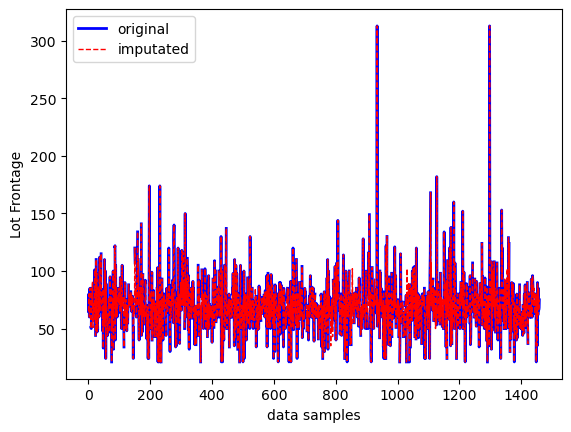

In [38]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(range(m),df[cleanCols[0]],'b',linewidth=2)
ax.plot(range(m),df3[cleanCols[0]],'r--',linewidth=1)
ax.set_xlabel('data samples')
ax.set_ylabel('Lot Frontage')
ax.legend(['original','imputated'])

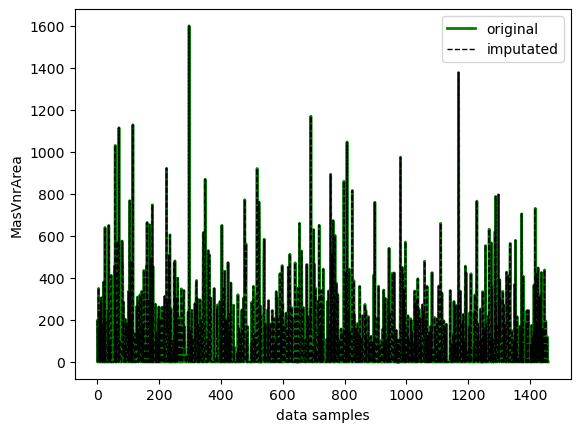

In [39]:
fig, ax = plt.subplots(1)
ax.plot(range(m),df[cleanCols[1]],'g',linewidth=2)
ax.plot(range(m),df3[cleanCols[1]],'k--',linewidth=1)
ax.set_xlabel('data samples')
ax.set_ylabel('MasVnrArea')
ax.legend(['original','imputated'])

In [40]:
# defining imputation stragety for object columns
imp2 = SimpleImputer( strategy='most_frequent')

In [41]:
# data imputation for object columns with most frequency strategy
for col in cleanCols:
    if df3[col].dtypes == 'object':
        print(col)
        df3[col] = imp2.fit_transform(df3[col].values.reshape(-1,1)).reshape(-1)
df3.head()

BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Electrical
GarageType
GarageFinish
GarageQual
GarageCond


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [42]:
# Validate there is no null values in the dataset
df3.count()

Id               1460
MSSubClass       1460
MSZoning         1460
LotFrontage      1460
LotArea          1460
                 ... 
MoSold           1460
YrSold           1460
SaleType         1460
SaleCondition    1460
SalePrice        1460
Length: 75, dtype: int64

In [43]:
from sklearn.preprocessing import LabelEncoder

In [44]:
# Create an instance of the LabelEncoder
label_encoder = LabelEncoder()

In [45]:
# checking columns with 'object' data type
newCols = df3.columns
objectCols = []
for col in newCols:
    if df3[col].dtypes == 'object':
        objectCols.append(col)
objectCols

['MSZoning',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'SaleType',
 'SaleCondition']

In [46]:
cat_map =[]
for i in objectCols:
    cats = pd.unique(df3[i])
    cat_dict = {}
    cats = sorted(cats)
    for j in range(len(cats)):
        cat_dict[cats[j]] = j
    cat_map.append(cat_dict)
cat_map

[{'C (all)': 0, 'FV': 1, 'RH': 2, 'RL': 3, 'RM': 4},
 {'Grvl': 0, 'Pave': 1},
 {'IR1': 0, 'IR2': 1, 'IR3': 2, 'Reg': 3},
 {'Bnk': 0, 'HLS': 1, 'Low': 2, 'Lvl': 3},
 {'AllPub': 0, 'NoSeWa': 1},
 {'Corner': 0, 'CulDSac': 1, 'FR2': 2, 'FR3': 3, 'Inside': 4},
 {'Gtl': 0, 'Mod': 1, 'Sev': 2},
 {'Blmngtn': 0,
  'Blueste': 1,
  'BrDale': 2,
  'BrkSide': 3,
  'ClearCr': 4,
  'CollgCr': 5,
  'Crawfor': 6,
  'Edwards': 7,
  'Gilbert': 8,
  'IDOTRR': 9,
  'MeadowV': 10,
  'Mitchel': 11,
  'NAmes': 12,
  'NPkVill': 13,
  'NWAmes': 14,
  'NoRidge': 15,
  'NridgHt': 16,
  'OldTown': 17,
  'SWISU': 18,
  'Sawyer': 19,
  'SawyerW': 20,
  'Somerst': 21,
  'StoneBr': 22,
  'Timber': 23,
  'Veenker': 24},
 {'Artery': 0,
  'Feedr': 1,
  'Norm': 2,
  'PosA': 3,
  'PosN': 4,
  'RRAe': 5,
  'RRAn': 6,
  'RRNe': 7,
  'RRNn': 8},
 {'Artery': 0,
  'Feedr': 1,
  'Norm': 2,
  'PosA': 3,
  'PosN': 4,
  'RRAe': 5,
  'RRAn': 6,
  'RRNn': 7},
 {'1Fam': 0, '2fmCon': 1, 'Duplex': 2, 'Twnhs': 3, 'TwnhsE': 4},
 {'1.5Fin'

In [47]:
# Fit and transform the data for labeling
df3[objectCols] = df3[objectCols].apply(label_encoder.fit_transform)
df3.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,3,3,0,4,...,0,0,0,0,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,3,3,0,2,...,0,0,0,0,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,0,3,0,4,...,0,0,0,0,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,0,3,0,0,...,272,0,0,0,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,0,3,0,2,...,0,0,0,0,0,12,2008,8,4,250000


In [48]:
len(objectCols[20:])
len(objectCols)

37

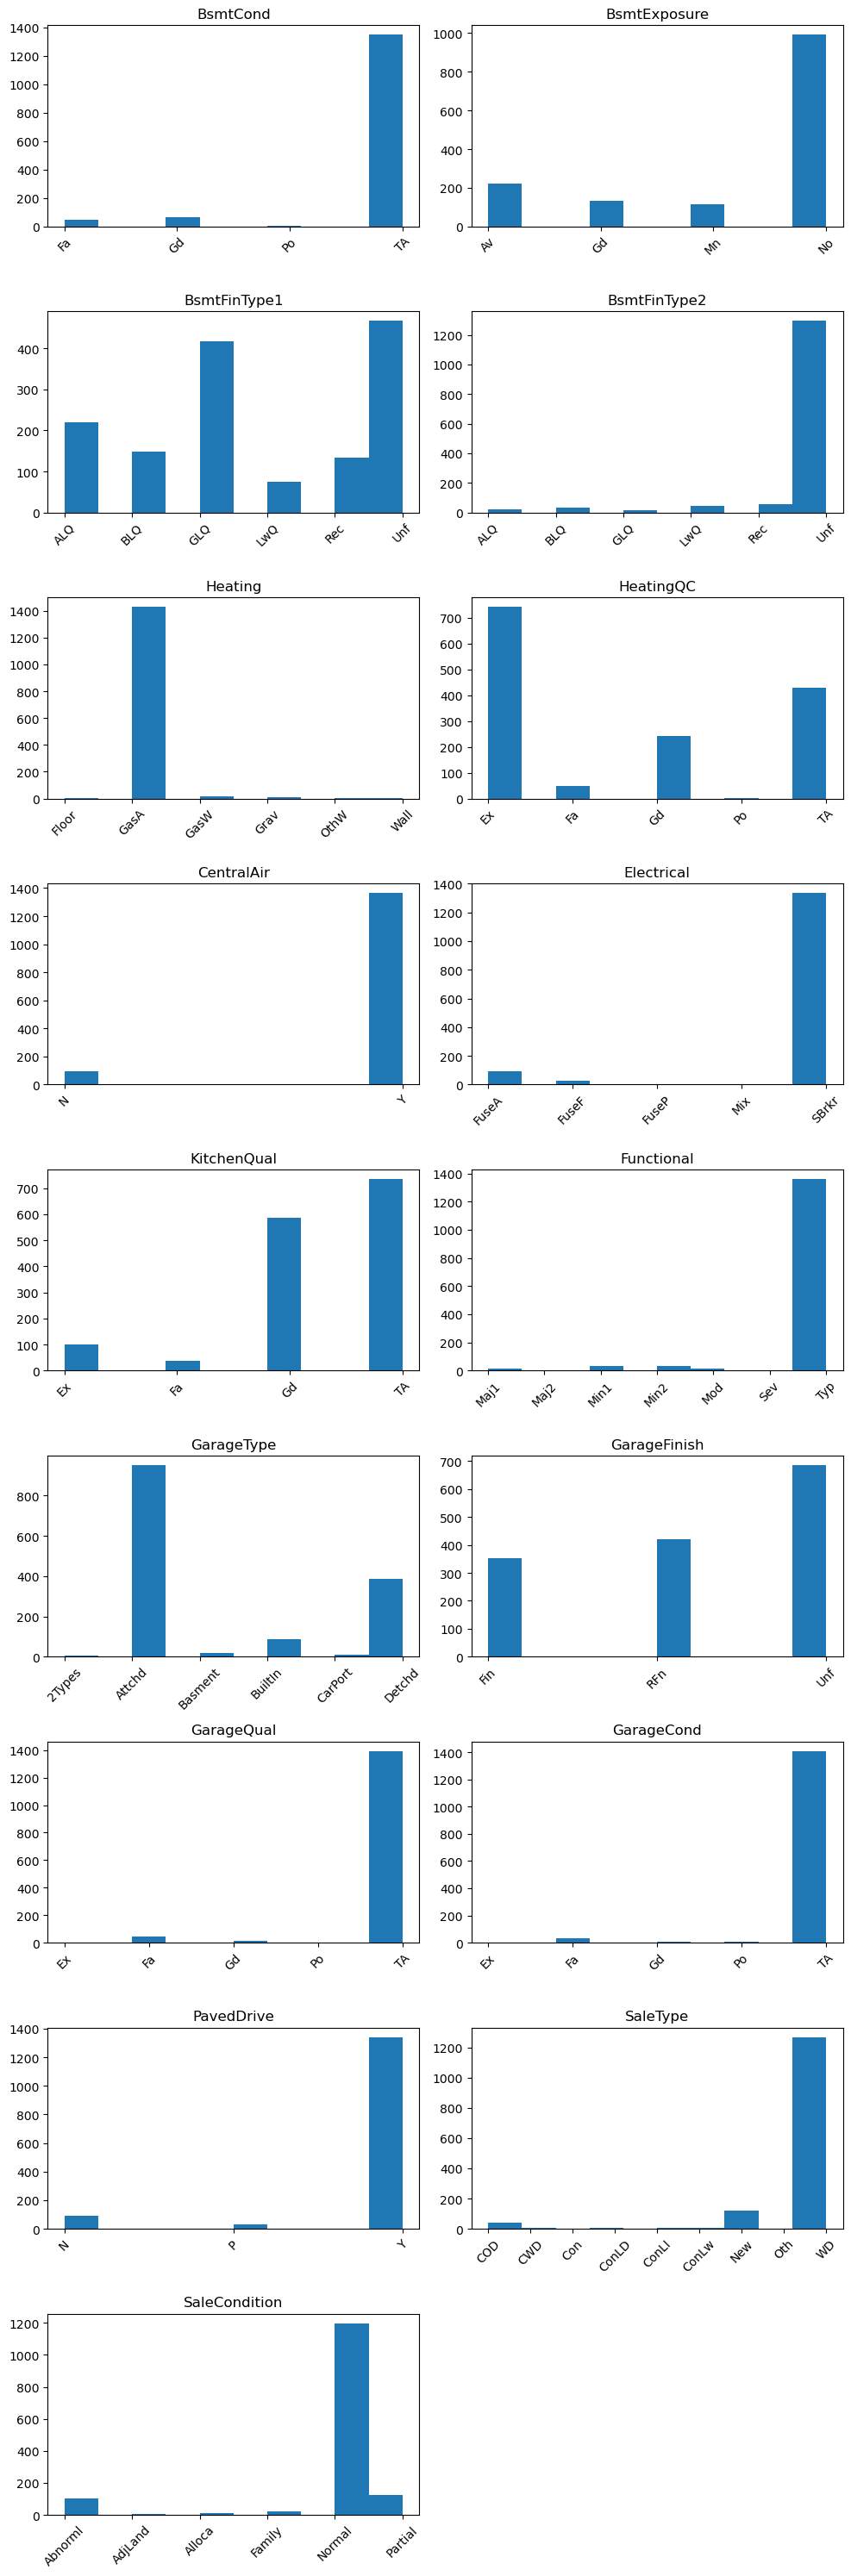

In [49]:
plt.figure(figsize=(10,30))
for i in range(len(objectCols[20:])):
    plt.subplot(9,2,i+1)
    plt.hist(df3[objectCols[i+20]])
    plt.title(objectCols[i+20])
     # Get the unique categories and their counts
    categories, counts = zip(*cat_map[i+20].items())
    # Set the positions and labels for xticks
    positions = range(len(categories))
    labels = categories
    # Set the xticklabels
    plt.xticks(positions, labels, rotation=45)  # Rotate labels for better readability
plt.tight_layout()

In [50]:
corr_matrix = df3.corr()

In [51]:
df3

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,3,3,0,4,...,0,0,0,0,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,3,3,0,2,...,0,0,0,0,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,0,3,0,4,...,0,0,0,0,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,0,3,0,0,...,272,0,0,0,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,0,3,0,2,...,0,0,0,0,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3,62.0,7917,1,3,3,0,4,...,0,0,0,0,0,8,2007,8,4,175000
1456,1457,20,3,85.0,13175,1,3,3,0,4,...,0,0,0,0,0,2,2010,8,4,210000
1457,1458,70,3,66.0,9042,1,3,3,0,4,...,0,0,0,0,2500,5,2010,8,4,266500
1458,1459,20,3,68.0,9717,1,3,3,0,4,...,112,0,0,0,0,4,2010,8,4,142125


In [52]:
import seaborn as sns

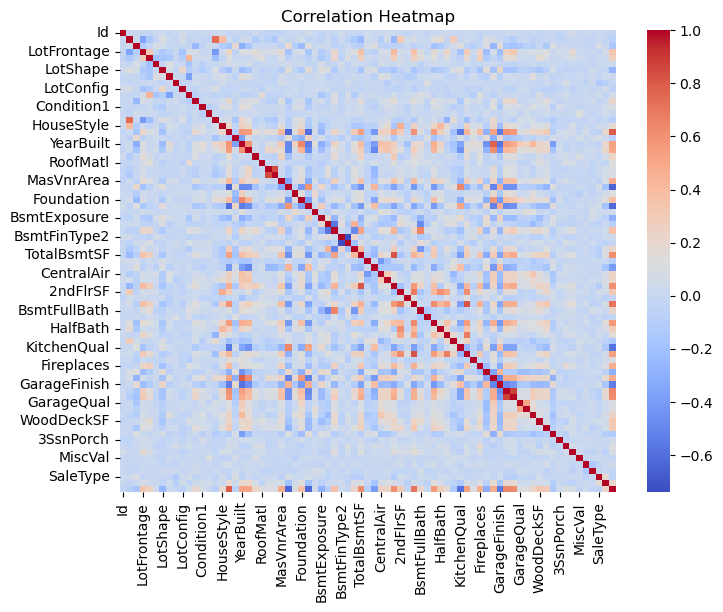

In [53]:
# Assuming corr_matrix contains your correlation matrix
# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [54]:
print(len(newCols))
newCols

75


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enclo

In [55]:
corr_coeff = np.zeros((len(newCols)-2))
corr_coeff.shape 

(73,)

In [56]:
corr_coeff = np.zeros((len(newCols)-2))
posInfluentCols = []
negInfluentCols = []
nonInfluentCols = []
for i in range(1,len(newCols)-1):
    corr_coeff[i-1] = df3[newCols[i]].corr(df3[newCols[-1]])
    if (corr_coeff[i-1] > -0.2) and (corr_coeff[i-1] < 0.2):
        nonInfluentCols.append(newCols[i])
    elif corr_coeff[i-1] < -0.2:
        negInfluentCols.append(newCols[i])
    else:
        posInfluentCols.append(newCols[i])

In [57]:
print(nonInfluentCols)
len(nonInfluentCols)

['MSSubClass', 'MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallCond', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterCond', 'BsmtCond', 'BsmtFinType1', 'BsmtFinType2', 'BsmtFinSF2', 'Heating', 'LowQualFinSF', 'BsmtHalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'Functional', 'GarageQual', 'GarageCond', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType']


36

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [58]:
df3[newCols[1:-1]]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,3,3,0,4,0,...,61,0,0,0,0,0,2,2008,8,4
1,20,3,80.0,9600,1,3,3,0,2,0,...,0,0,0,0,0,0,5,2007,8,4
2,60,3,68.0,11250,1,0,3,0,4,0,...,42,0,0,0,0,0,9,2008,8,4
3,70,3,60.0,9550,1,0,3,0,0,0,...,35,272,0,0,0,0,2,2006,8,0
4,60,3,84.0,14260,1,0,3,0,2,0,...,84,0,0,0,0,0,12,2008,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,3,62.0,7917,1,3,3,0,4,0,...,40,0,0,0,0,0,8,2007,8,4
1456,20,3,85.0,13175,1,3,3,0,4,0,...,0,0,0,0,0,0,2,2010,8,4
1457,70,3,66.0,9042,1,3,3,0,4,0,...,60,0,0,0,0,2500,5,2010,8,4
1458,20,3,68.0,9717,1,3,3,0,4,0,...,0,112,0,0,0,0,4,2010,8,4


In [59]:
X = df3[newCols[1:-1]].values
X.shape

(1460, 73)

In [60]:
X[:,:10]

array([[60.,  3., 65., ...,  0.,  4.,  0.],
       [20.,  3., 80., ...,  0.,  2.,  0.],
       [60.,  3., 68., ...,  0.,  4.,  0.],
       ...,
       [70.,  3., 66., ...,  0.,  4.,  0.],
       [20.,  3., 68., ...,  0.,  4.,  0.],
       [20.,  3., 75., ...,  0.,  4.,  0.]])

In [61]:
y = df3[newCols[-1]].values
print(y.shape)
y[:10]

(1460,)


array([208500, 181500, 223500, 140000, 250000, 143000, 307000, 200000,
       129900, 118000], dtype=int64)

In [62]:
from sklearn.preprocessing import StandardScaler

In [65]:
# Normalize the input features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.07337496, -0.04553194, -0.22937175, ...,  0.13877749,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194,  0.4519361 , ..., -0.61443862,
         0.31386709,  0.2085023 ],
       [ 0.07337496, -0.04553194, -0.09311018, ...,  0.13877749,
         0.31386709,  0.2085023 ],
       ...,
       [ 0.30985939, -0.04553194, -0.18395123, ...,  1.64520971,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194, -0.09311018, ...,  1.64520971,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194,  0.22483348, ...,  0.13877749,
         0.31386709,  0.2085023 ]])

## Split Dataset into Training and Test Datasets

In [67]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((1168, 73), (292, 73))

In [68]:
# Create a linear regression model
model = LinearRegression()

In [69]:
# Fit the model to the training data
model.fit(X_train, y_train)

LinearRegression()

In [73]:
model.intercept_, model.coef_

(180461.0419520548,
 array([-6.20100985e+03, -1.50858831e+03, -5.06548754e+03,  3.15336388e+03,
         1.26034209e+03, -1.62453406e+03,  2.43506994e+03, -1.27698666e+03,
        -1.49742587e+02,  3.57759100e+03,  2.74355463e+03, -2.82791383e+02,
        -2.58794845e+03, -2.51236270e+03, -2.60564796e+03,  1.60900804e+04,
         4.68121156e+03,  5.37320286e+03,  1.81462811e+03,  2.37755373e+03,
         2.46256541e+03, -4.11651165e+03,  2.28384144e+03,  3.17051463e+03,
        -5.38991357e+03,  3.76727294e+01,  8.70712122e+02, -9.07493105e+03,
         2.48887458e+03, -4.27677752e+03, -1.47355643e+03,  8.79417558e+16,
         6.93251741e+02,  3.11044935e+16,  8.51978043e+16, -8.45882000e+16,
        -3.28994237e+02, -4.76577697e+02,  1.78011456e+02, -4.87308687e+02,
        -2.81682039e+16, -3.18070668e+16, -3.54285648e+15,  3.82884327e+16,
         4.44882526e+03, -1.92112569e+02,  1.43851080e+03, -5.28751380e+02,
        -1.89573741e+03, -2.28704428e+03, -8.11290031e+03,  5.474710

In [74]:
# Make predictions on the testing data
y_pred = model.predict(X_test)
# Calculate R-squared value
r_squared = r2_score(y_test, y_pred)

In [78]:
# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)
print("R-squared value:", r_squared)
print("Mean Squared Error:", mse)

R-squared value: 0.8455877810807907
Mean Squared Error: 1184392089.4859266


In [79]:
LotAreaMean = X[:,3].mean()
LotAreaStd = X[:,3].std()
LotAreaMean,LotAreaStd

(10516.828082191782, 9977.846105448105)

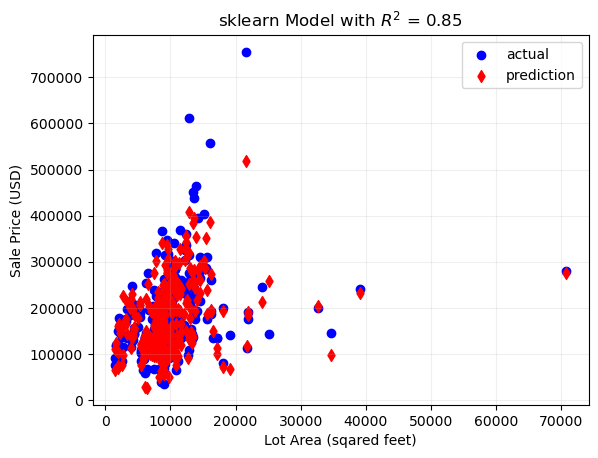

In [80]:
# Plot the data
fig, ax = plt.subplots()
ax.scatter(X_test[:, 3]*LotAreaStd+LotAreaMean, y_test, color='b', marker='o')
ax.scatter(X_test[:, 3]*LotAreaStd+LotAreaMean, y_pred, color='r', marker='d')
ax.set_xlabel('Lot Area (sqared feet)')
ax.set_ylabel('Sale Price (USD)')
ax.legend(['actual','prediction'])
ax.set_title(f'sklearn Model with $R^{2}$ = {r_squared:.2f}')
ax.grid(alpha=0.2)
plt.show()

In [74]:
## Using Influential Feature

In [82]:
InfluentCols = posInfluentCols + negInfluentCols
InfluentCols

['LotFrontage',
 'LotArea',
 'Neighborhood',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'MasVnrArea',
 'Foundation',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'BsmtFullBath',
 'FullBath',
 'HalfBath',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'SaleCondition',
 'LotShape',
 'ExterQual',
 'BsmtQual',
 'BsmtExposure',
 'HeatingQC',
 'KitchenQual',
 'GarageType',
 'GarageFinish']

In [83]:
X_reduced = df3[InfluentCols].values
X_reduced.shape

(1460, 37)

In [84]:
# Normalize the input features
scaler = StandardScaler()
X_reduced_scaled = scaler.fit_transform(X_reduced)
X_reduced_scaled.shape

(1460, 37)

In [85]:
# Split the data into training and testing sets
X_reduced_train, X_reduced_test, y_reduced_train, y_reduced_test = train_test_split(X_reduced_scaled, y, test_size=0.2, random_state=42)
X_reduced_test.shape

(292, 37)

In [86]:
# Create a linear regression model
model2 = LinearRegression()

In [87]:
# Fit the model to the training data
model2.fit(X_reduced_train, y_reduced_train)

LinearRegression()

In [88]:
model2.intercept_, model2.coef_

(180384.91390451143,
 array([-1951.35772413,  4805.49757417,  2011.60041714, 18576.61186658,
         1249.80928935,  2838.61034187,  2653.87677754,  2716.94942311,
          710.4267075 ,  1856.67461282, -2195.99543443,  2939.84367233,
         2849.53716234,  -318.30089537,  7339.19335818,  6022.76142649,
        10525.9072317 ,  3336.58132987,   321.51419937,   746.19498206,
         3448.65461907,  4065.77810736, -1794.7374136 ,  7242.58677003,
         2267.20786725,  1761.91266356,  2077.01435994,   125.0913887 ,
         1855.93769988, -2708.0620924 , -4846.49093293, -7823.1218115 ,
        -3351.39143907, -1640.44183549, -8917.58151314, -2121.34940109,
          227.86387663]))

In [89]:
# Make predictions on the testing data
y_reduced_pred = model2.predict(X_reduced_test)
# Calculate R-squared value
r_squared_reduced = r2_score(y_reduced_test, y_reduced_pred)
# Calculate mean squared error
mse_reduced = mean_squared_error(y_reduced_test, y_reduced_pred)
print("R-squared value:", r_squared_reduced)
print("Mean Squared Error:", mse_reduced)

R-squared value: 0.8388973782038281
Mean Squared Error: 1235709662.009733


In [90]:
LotAreaMean = X_reduced[:,1].mean()
LotAreaStd = X_reduced[:,1].std()
LotAreaStd

9977.846105448105

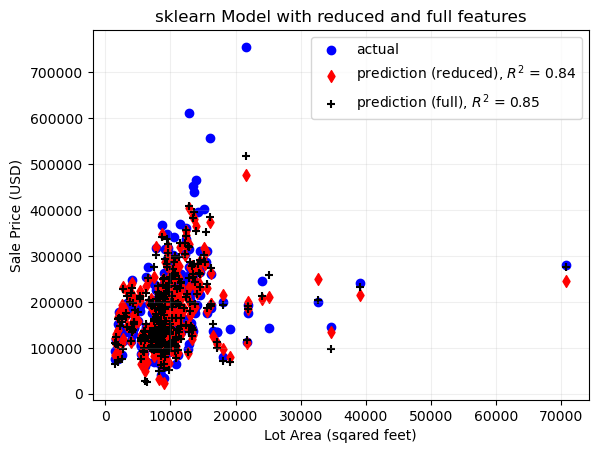

In [91]:
# Plot the data
fig, ax = plt.subplots()
ax.scatter(X_reduced_test[:, 1]*LotAreaStd+LotAreaMean, y_reduced_test, color='b', marker='o')
ax.scatter(X_reduced_test[:, 1]*LotAreaStd+LotAreaMean, y_reduced_pred, color='r', marker='d')
ax.scatter(X_test[:, 3]*LotAreaStd+LotAreaMean, y_pred, color='k', marker='+')
ax.set_xlabel('Lot Area (sqared feet)')
ax.set_ylabel('Sale Price (USD)')
leg_red = f'prediction (reduced), $R^{2}$ = {r_squared_reduced:.2f}'
leg_full = f'prediction (full), $R^{2}$ = {r_squared:.2f}'
ax.legend(['actual',leg_red, leg_full])
ax.set_title(f'sklearn Model with reduced and full features')
ax.grid(alpha=0.2)
plt.show()

In [92]:
def cost(X,y,theta):
    m = X.shape[0]
    J = 1/(2*m)*np.sum((X@theta-y)**2)
    dJdtheta = 1/m*(X.T@(X@theta-y))
    return J, dJdtheta

In [93]:
n2 = X_reduced_train.shape[1]+1
n2

38

In [94]:
X_reduced_train.shape
m = X_reduced_train.shape[0]

In [95]:
X_reduced_train2 = np.c_[(np.ones((m,1)),X_reduced_train)]
X_reduced_train2[:5,:]

array([[ 1.00000000e+00, -2.26913523e-03, -2.12152809e-01,
        -4.18136140e-02, -7.95151472e-01, -4.72560418e-01,
        -1.35019385e+00, -4.91515732e-01, -5.74410469e-01,
        -5.49162133e-01,  1.04916944e+00, -3.96726783e-01,
         5.85036117e-01,  2.63812565e-01,  3.02403428e-01,
         3.91696734e-01, -7.95163227e-01, -3.83520936e-01,
         1.10781015e+00, -1.02604084e+00, -7.61620672e-01,
        -9.34129784e-01, -9.51226488e-01, -8.96599560e-01,
        -1.02685765e+00, -8.37406028e-01,  2.89744763e-01,
         1.24310154e+00, -7.04483250e-01,  2.08502298e-01,
         7.50730558e-01,  6.63451436e-01,  8.32968528e-01,
         6.28911842e-01,  1.41560982e+00,  7.95628728e-01,
        -6.86776352e-01, -2.81886753e-01],
       [ 1.00000000e+00, -5.01894895e-01, -2.68577813e-01,
        -7.07185563e-01, -7.18361143e-02,  7.19786353e-01,
         4.42586404e-01, -4.91515732e-01, -5.74410469e-01,
         8.35599031e-01, -9.73018183e-01,  5.24680555e-01,
        -5.89

In [96]:
X_reduced_train2[:,0]

array([1., 1., 1., ..., 1., 1., 1.])

In [104]:
theta = np.random.rand((n2))
alpha = 0.018
maxIter = 1000
J = np.zeros((maxIter,1))
for i in range(maxIter):
    J[i],dJdtheta = cost(X_reduced_train2,y_reduced_train,theta)
    theta -= alpha*dJdtheta
    if i%100 == 0:
        print(f"{i:d}, J = {J[i][0]:.2f}")

0, J = 19442300842.23
100, J = 990825317.93
200, J = 555884024.22
300, J = 541390247.49
400, J = 540216489.25
500, J = 539851085.48
600, J = 539667822.01
700, J = 539563248.13
800, J = 539499515.95
900, J = 539458990.97


Text(0, 0.5, 'cost function')

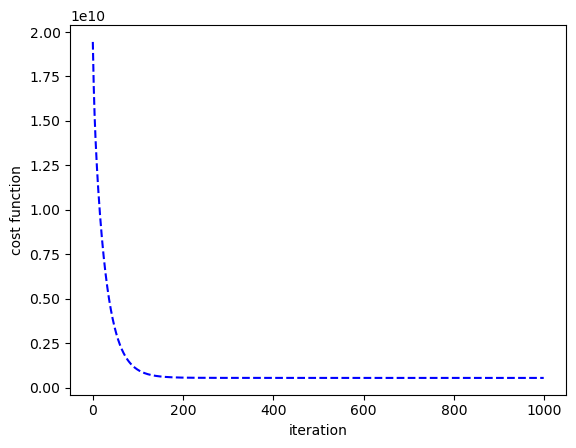

In [105]:
plt.plot(np.arange(maxIter),J,'b--')
plt.xlabel('iteration')
plt.ylabel('cost function')

In [106]:
m = X_reduced_test.shape[0]
X_reduced_test2 = np.c_[(np.ones((m,1)),X_reduced_test)]
X_reduced_test2[:5,:]

array([[ 1.00000000e+00, -2.26913523e-03, -2.10749701e-01,
         1.12258730e+00, -7.18361143e-02, -2.73835956e-01,
         8.78668088e-01,  1.90452089e+00, -5.74410469e-01,
        -5.49162133e-01,  4.81114568e-01, -3.87671183e-01,
         3.58118763e-03,  2.63812565e-01,  3.02403428e-01,
        -2.44858091e-01, -7.95163227e-01, -8.51824412e-01,
        -8.19964365e-01, -1.02604084e+00, -7.61620672e-01,
        -3.18683266e-01, -9.51226488e-01, -6.46457443e-01,
        -1.02685765e+00, -9.77768983e-01,  2.89744763e-01,
         7.80197185e-01, -7.04483250e-01,  2.08502298e-01,
         7.50730558e-01,  6.63451436e-01,  8.32968528e-01,
         6.28911842e-01,  1.41560982e+00,  7.95628728e-01,
        -6.86776352e-01, -2.81886753e-01],
       [ 1.00000000e+00,  1.26950552e+00,  1.74303342e-01,
         4.57215348e-01,  1.37479460e+00,  7.52907096e-01,
         4.91039924e-01, -4.91515732e-01,  1.43104900e+00,
         8.35599031e-01,  1.29042827e+00, -3.08434679e-01,
         9.24

In [107]:
h_test = X_reduced_test2@theta
h_test[:5],y_reduced_test[:5]

(array([135978.23414049, 322998.81560789, 113460.11319908, 157426.49529951,
        326975.71735218]),
 array([154500, 325000, 115000, 159000, 315500], dtype=int64))

In [108]:
SS_tot = np.sum((y_reduced_train-np.mean(y_reduced_train))**2)
SS_res = np.sum((y_reduced_train-h)**2)
R_squared = 1- SS_res/SS_tot
R_squared,SS_res

(0.819018491347026, 1260824844963.6802)

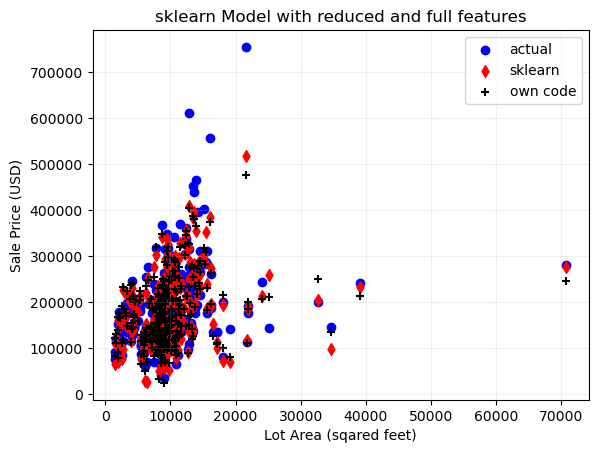

In [109]:
# Plot the data
fig, ax = plt.subplots()
ax.scatter(X_reduced_test[:, 1]*LotAreaStd+LotAreaMean, y_reduced_test, color='b', marker='o')
ax.scatter(X_reduced_test[:, 1]*LotAreaStd+LotAreaMean, y_pred, color='r', marker='d')
ax.scatter(X_test[:, 3]*LotAreaStd+LotAreaMean, h_test, color='k', marker='+')
ax.set_xlabel('Lot Area (sqared feet)')
ax.set_ylabel('Sale Price (USD)')
leg_red = f'prediction (reduced), $R^{2}$ = {r_squared_reduced:.2f}'
leg_full = f'prediction (full), $R^{2}$ = {r_squared:.2f}'
ax.legend(['actual','sklearn','own code'])
ax.set_title(f'sklearn Model with reduced and full features')
ax.grid(alpha=0.2)
plt.show()